<a href="https://colab.research.google.com/github/HubaIftikhar-SE/CODSOFT/blob/main/fcc_MAGIC_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler


## Bock, R. (2004). MAGIC Gamma Telescope [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52C8B.

***import file from the desktop***

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving magic04.data to magic04 (1).data


In [ ]:
df=pd.read_csv('magic04.data')
print(df)


        28.7967   16.0021  2.6449  0.3918  0.1982   27.7004    22.011  \
0       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
1      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
2       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
3       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
4       51.6240   21.1502  2.9085  0.2420  0.1340   50.8761   43.1887   
...         ...       ...     ...     ...     ...       ...       ...   
19014   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19015   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19016   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19017  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19018  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       -8.2027   40.092   81.8828  g  
0      -9.9574   6.3609  205.2610  g  
1     -45.2160  76.9600  256.7880  g  
2     

# Column names are not present hence,

In [ ]:
cols = [ "fLength", "fwidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "flpha", "fDist","class"]
df=pd.read_csv('magic04.data', names=cols)

# Preview the first 5 rows of a DataFrame

In [ ]:
df.head()

,fLength,fwidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,flpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


# Find all the distinct values present in a specific column

In [ ]:
df['class'].unique()

array(['g', 'h'], dtype=object)

# Converts values in the "class" column into numbers (0 and 1)

In [ ]:
df['class']=(df['class']=='g').astype(int)

# If blue and red are:

# completely separate → feature is very useful
# heavily overlapping → weak feature

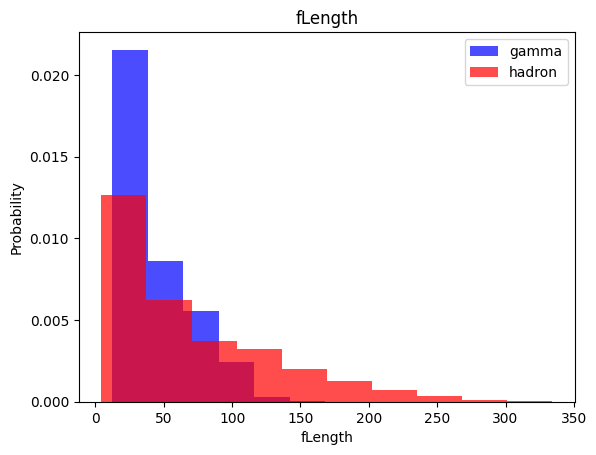

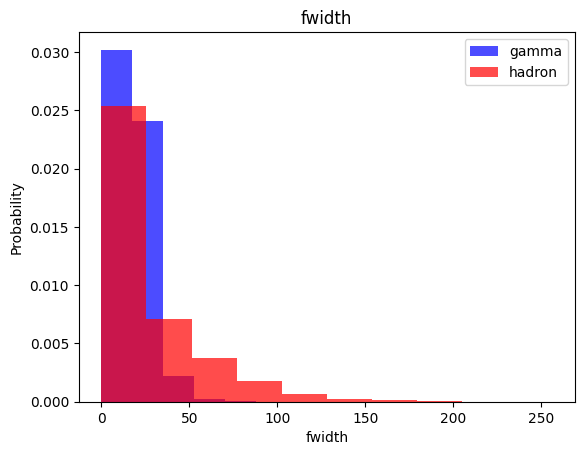

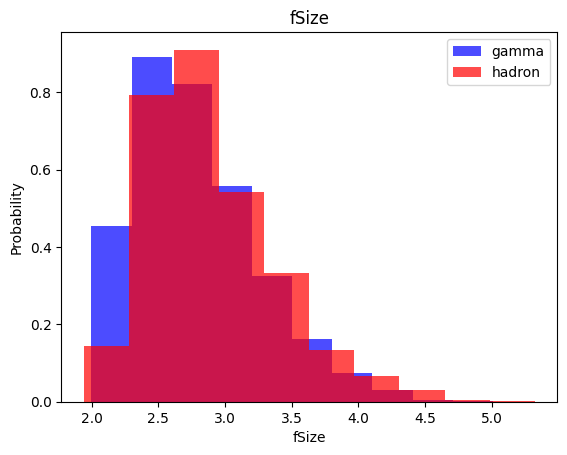

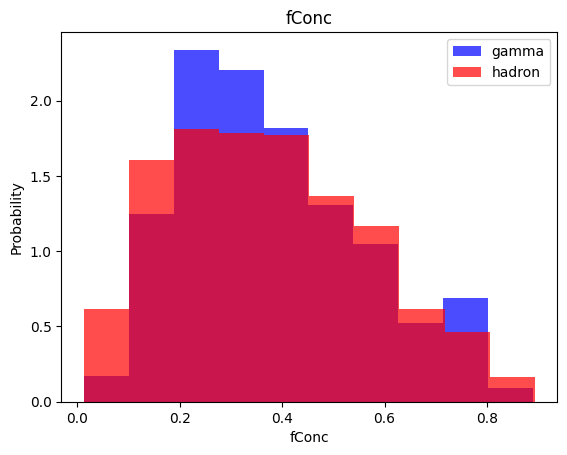

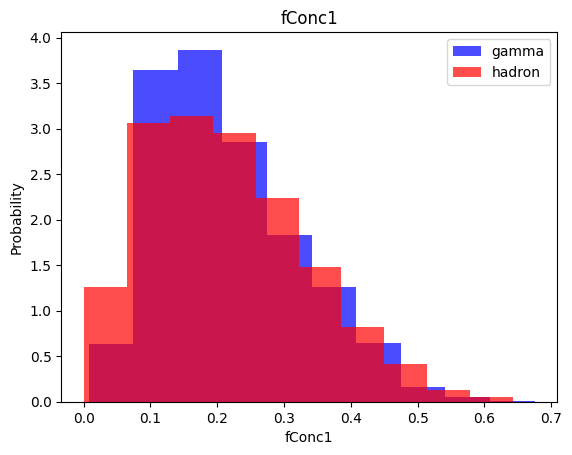

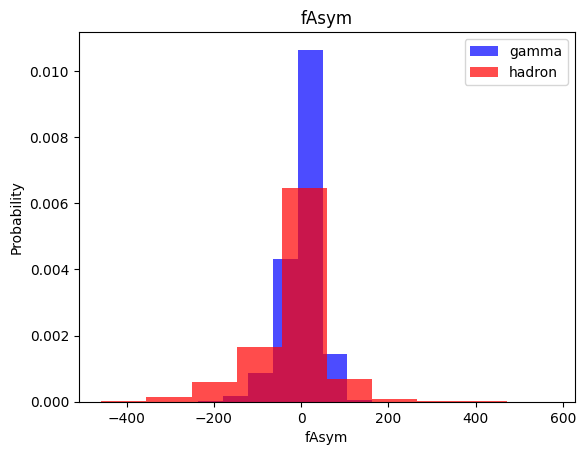

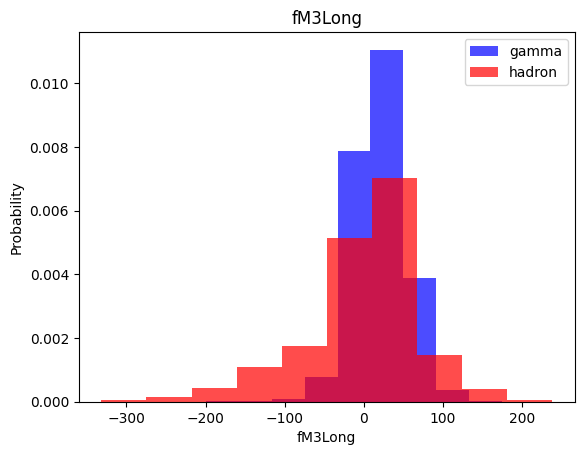

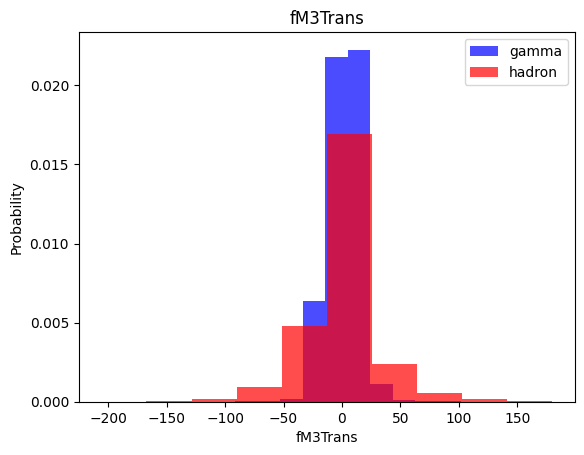

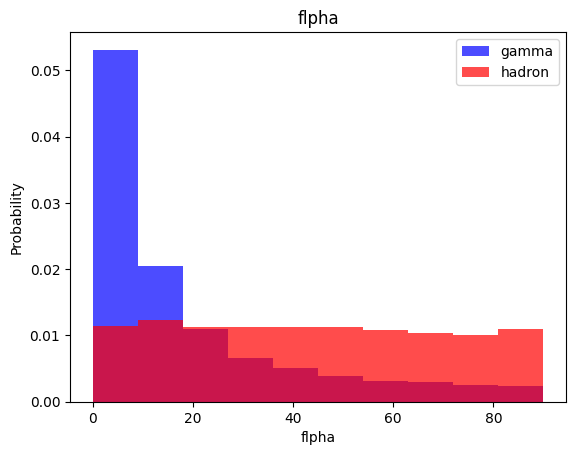

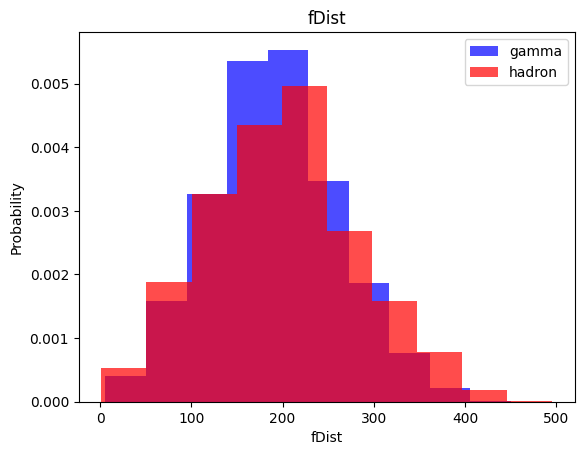

In [ ]:
for label in cols[:-1]:

    plt.hist(
        df[df["class"] == 1][label],
        color='blue',
        label='gamma',
        alpha=0.7,
        density=True
    )

    plt.hist(
        df[df["class"] == 0][label],
        color='red',
        label='hadron',
        alpha=0.7,
        density=True
    )

    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)

    plt.legend()
    plt.show()

# Shuffles the dataset and splits it into 60% train, 20% validation, 20% test

In [ ]:
train, valid, test = np.split(
    df.sample(frac=1),
    [int(0.6*len(df)), int(0.8*len(df))]
)



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


# Separates features and labels, scales features, and returns processed data for machine learning.

In [ ]:
def scale_dataset(dataframe, oversample=False):
    X = dataframe[:, :-1]
    y = dataframe[:, -1]

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))

    return data, X, y

# How many gamma samples are in the training data?

In [ ]:
len(train[train[:, -1] == 1])

7384

# How many hadrons samples are in the training data?

In [ ]:
len(train[train[:, -1] == 0])

7384

# So that might actually become an issue. And instead, what we want to do is we want to oversample



# Balancing minority class

In [ ]:
train, X_train, y_train = scale_dataset(train, oversample=True)

In [ ]:
len(y_train)

14768

In [ ]:
sum(y_train == 1)

np.int64(7384)

In [ ]:
sum(y_train == 0)

np.int64(7384)

#  Why we only oversample TRAIN:

# Because:
#  Training is where model learns
# We can “help” it learn balanced patterns there

# But:
# validation/test = must stay REAL
# So we can see true performance


 We don’t fully trust oversampling because it duplicates data, which can make the model overfit and look better than it really is.

In [ ]:
train, X_train, y_train = scale_dataset(train, oversample=True)

valid, X_valid, y_valid = scale_dataset(valid.values, oversample=False)

test, X_test, y_test = scale_dataset(test.values, oversample=False)

# KNN is a machine learning algorithm that predicts the output of new data by comparing it with the most similar existing data points.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Creates KNN model

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=1)

# n_neighbors=1 means:
# model looks at 1 nearest data point and copies its class

# Model learns from training data.



In [ ]:
knn_model.fit(X_train, y_train)

# X_train = features/input
# y_train = correct answers/classes

KNeighborsClassifier(n_neighbors=1)

# Predict on test data

In [ ]:
y_pred = knn_model.predict(X_test)

# Predicted output

In [ ]:
y_pred

array([1., 1., 0., ..., 1., 1., 1.])

# Real answers

In [ ]:
y_test


array([0., 1., 1., ..., 1., 1., 1.])

# Detailed performance report of your ML model predictions

In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.73      0.71      0.72      1330
         1.0       0.85      0.86      0.85      2474

    accuracy                           0.81      3804
   macro avg       0.79      0.78      0.79      3804
weighted avg       0.80      0.81      0.81      3804



# Precision
*When model said YES, how often was it correct?*

# Recall
*Out of all actual YES cases, how many did the model correctly detect?*

# F1-score

Is the model good at BOTH?

# Accuracy

*Overall correct predictions %*

# Support

Number of real samples in each class

# Macro Average

Doesn’t care if class is big or small, equal importance to all classes

# Weighted Average


Bigger classes have more influence, importance based on class size